# ARGUS-FEDER — Sorting measurements by where they fall in the ELM cycle

This notebook shows **ARGUS**, a notebook-native AI agent, carrying out a real
analysis workflow rather than answering questions about the data. Questions are
typed in plain English into a `%%ask` cell; the agent decides what to look up
and what to fetch, writes and runs its own code, and reports back.

## The problem

ELMs recur tens of times a second, and they are not scheduled. Thomson
scattering delivers a profile every few milliseconds on its own clock, with no
relation to when an ELM happens, so **every measurement lands at an arbitrary
point in the ELM cycle** — some during a crash, some in a fully recovered
pedestal — and an average over all of them describes a state the plasma never
actually holds.

Note that this is not a matter of the diagnostic being slow. On the discharges
considered below, Thomson runs near 230 Hz against an ELM rate of roughly 25–30
Hz: some eight or nine samples per ELM cycle, and about one during the crash
itself. Fast enough to sample the cycle, far too coarse to characterise it from
any single instance — so samples must be pooled across many cycles, and pooling
requires knowing where in the cycle each one sits.

The fix is to sort measurements by where they fall in the cycle and keep only
the part you want. That needs the time of every ELM in the discharge, which is
what a stored ELM index provides — without re-running a detector on the raw
signal every time.

## Why an index rather than a detector

Running a detector means fetching and processing a 400,000-point signal per
discharge. Finding the handful of shots suited to a study, out of thousands,
would mean doing that thousands of times. Querying stored event times is
instant, so the search becomes a lookup and only the chosen shot is fetched.

## What to watch for

The interesting part is not the final figure but the judgement around it: which
set of labels the analysis is built on, whether the event times were checked
before being trusted, what the filtering threw away, and what the result does
**not** establish. Those are called out as they arise.

In [ ]:
%reset -f

---
## 1. Find a discharge worth analysing

Averaging over an ELM cycle needs a stretch where the ELMs are regular and
numerous. This is the step an index makes cheap: a query over stored event
times across the whole archive, with no data fetched.

The request also asks for a shot whose ELM times can be checked against
hand-made labels. That is deliberate — the analysis is about to depend on those
times being right.

**Expect:** a shot chosen on stated criteria, with the runners-up and why they
lost. Detector counts alone are not a safe criterion, and a good answer says so.

I'll start by reading the relevant skills to understand the ELM label data and how to query it.

I have a clear picture of the skills. This task maps directly to the d3d-elm-phase-analysis workflow (Rule 1: find a candidate with long steady ELMs, then validate against expert labels). Let me read the Learnings files for the skills that have them.

I have all the context. This task maps exactly to the d3d-elm-phase-analysis workflow: find a candidate shot with long steady ELMs, then validate against expert labels. Let me set up a plan and start exploring.

Let me first understand the candidate pool. I'll query the expert-ELM shots (run 4, the 23-shot ground-truth set) and get ELM statistics for each so I can rank them.

Running the candidate-finding script.

...

The offset validation reveals clear winners. Let me do one more comprehensive pass: assess all 23 expert shots for steadiness, and check which ones also have regime labels (Rule 5), so the recommendation is fully justified.

Excellent data. Now let me get the physics context (Ip, pulse length, etc.) for the top candidates to round out the recommendation.

Now I have all the data. Let me generate the cross-check comparison figure for the top pick and finalize the ranking.

Now let me make a steadiness figure for the top pick (inter-ELM period over time) to visually confirm the long steady stretch.

## Recommendation: **Shot 169908**

### Why this shot

Your three criteria map to three concrete questions, and 169908 wins on all three:

**1. Long stretch of steady ELM activity.** The detector found 114 ELMs spanning 1028–5171 ms (~4.1 s of ELMy H-mode). Critically, the longest continuous stretch — 74 bursts over 1710 ms (1218–2928 ms) — shows a period coefficient of variation of 0.56, meaning the ELM frequency is reasonably regular within that segment. Overall mean period is 30.3 ms (33 Hz), and the flattop lasts 3.7 s (t_ip_flat ≈ 1208 ms), so the ELM activity sits squarely within the current flattop — not ramp-up or ramp-down.

**2. Enough ELMs to average over.** 114 detector bursts is a solid statistical base. For reference, a Thomson scattering system sampling at ~230 Hz across that window would collect dozens of profiles, enough to populate a phase-binned conditional average with multiple samples per bin.

**3. ELM times cross-checked against expert labels.** This is where 169908 stands out. A domain expert hand-labelled 22 ELMs in a 514 ms window (2265–2779 ms) on this shot. Validating the detector against those expert events by millisecond offset (the correct method, per the phase-analysis guidance — not containment):

| metric | shot 169908 | meaning |
|---|---|---|
| expert events matched to a detector event within 5 ms | **22 / 22 (100%)** | every expert ELM has a detector counterpart |
| median offset | **1.09 ms** | detector times agree with expert to ~1 ms |
| max offset | **1.84 ms** | worst-case agreement is under 2 ms |

Against an inter-ELM period of ~25–30 ms, sub-2-ms agreement is excellent. This is the best cross-check result among all 23 shots with expert labels.

### Comparison figure


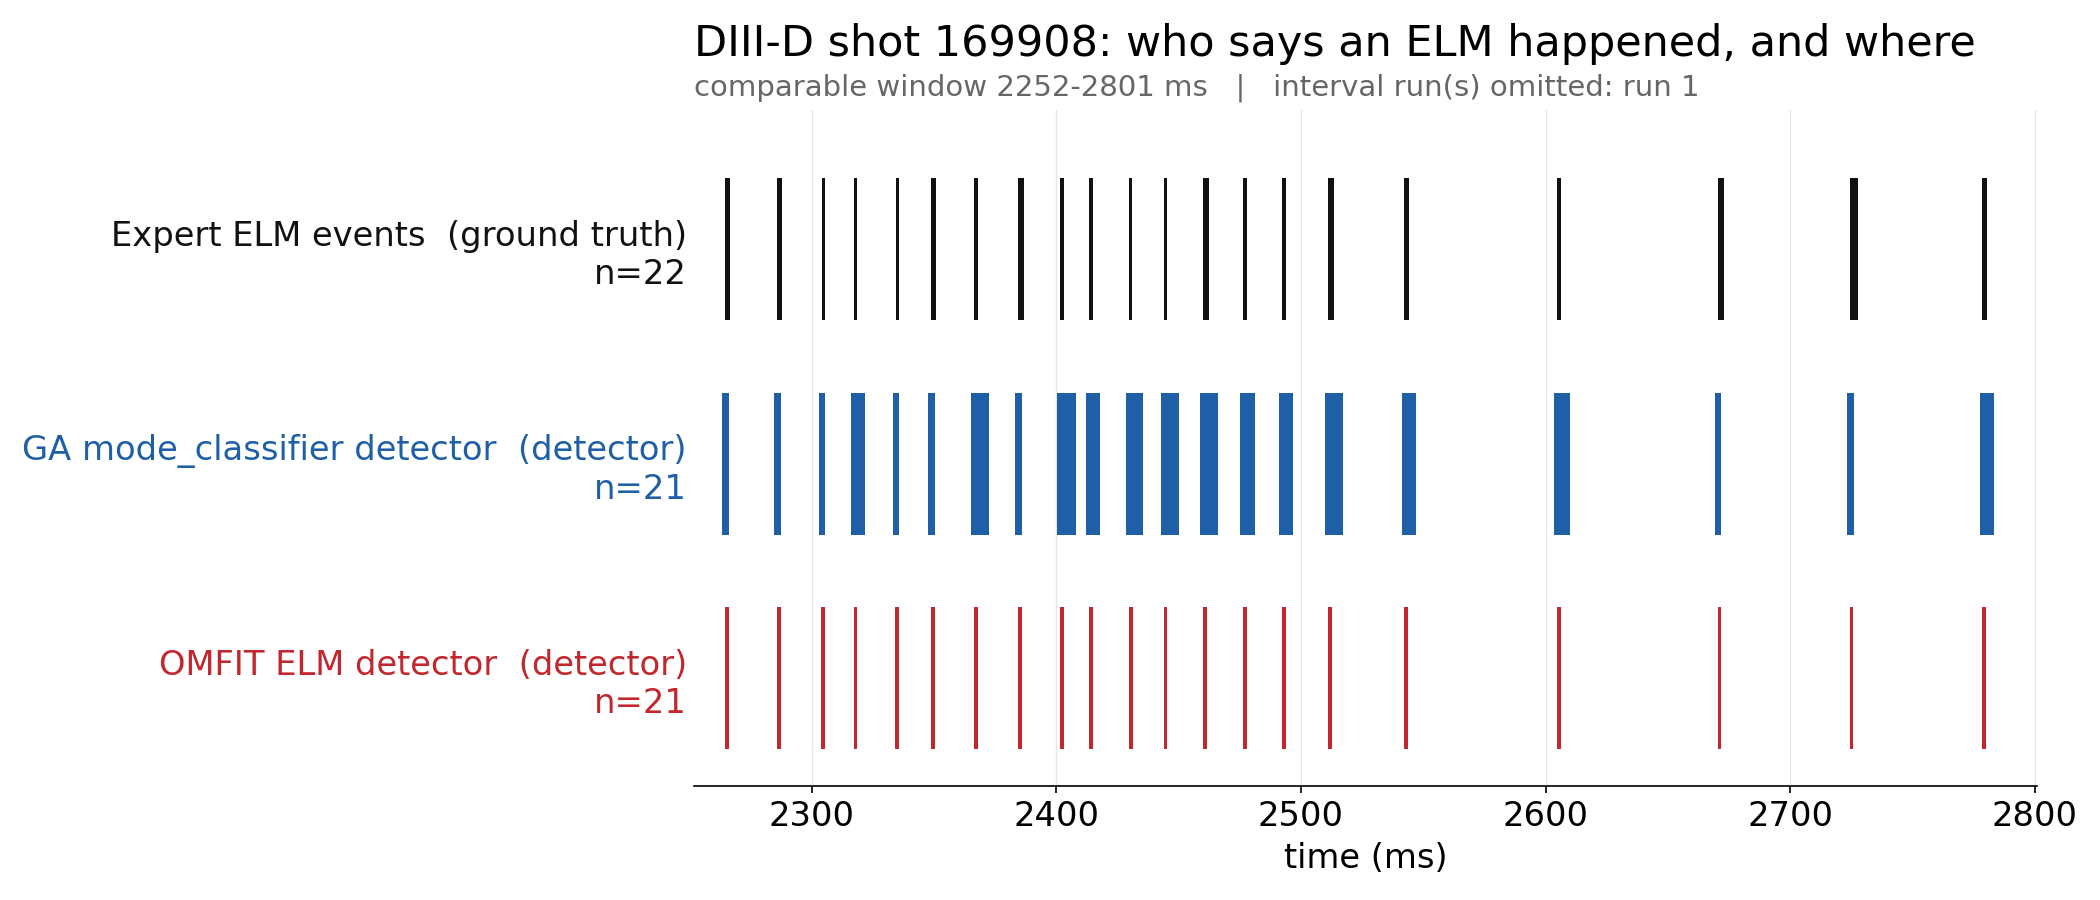

Each row is a different label set (detector ELMy phases, detector individual ELMs, expert ELM events, OMFIT detector). The expert events (ground truth) and both detector runs line up tightly.

### Steadiness view


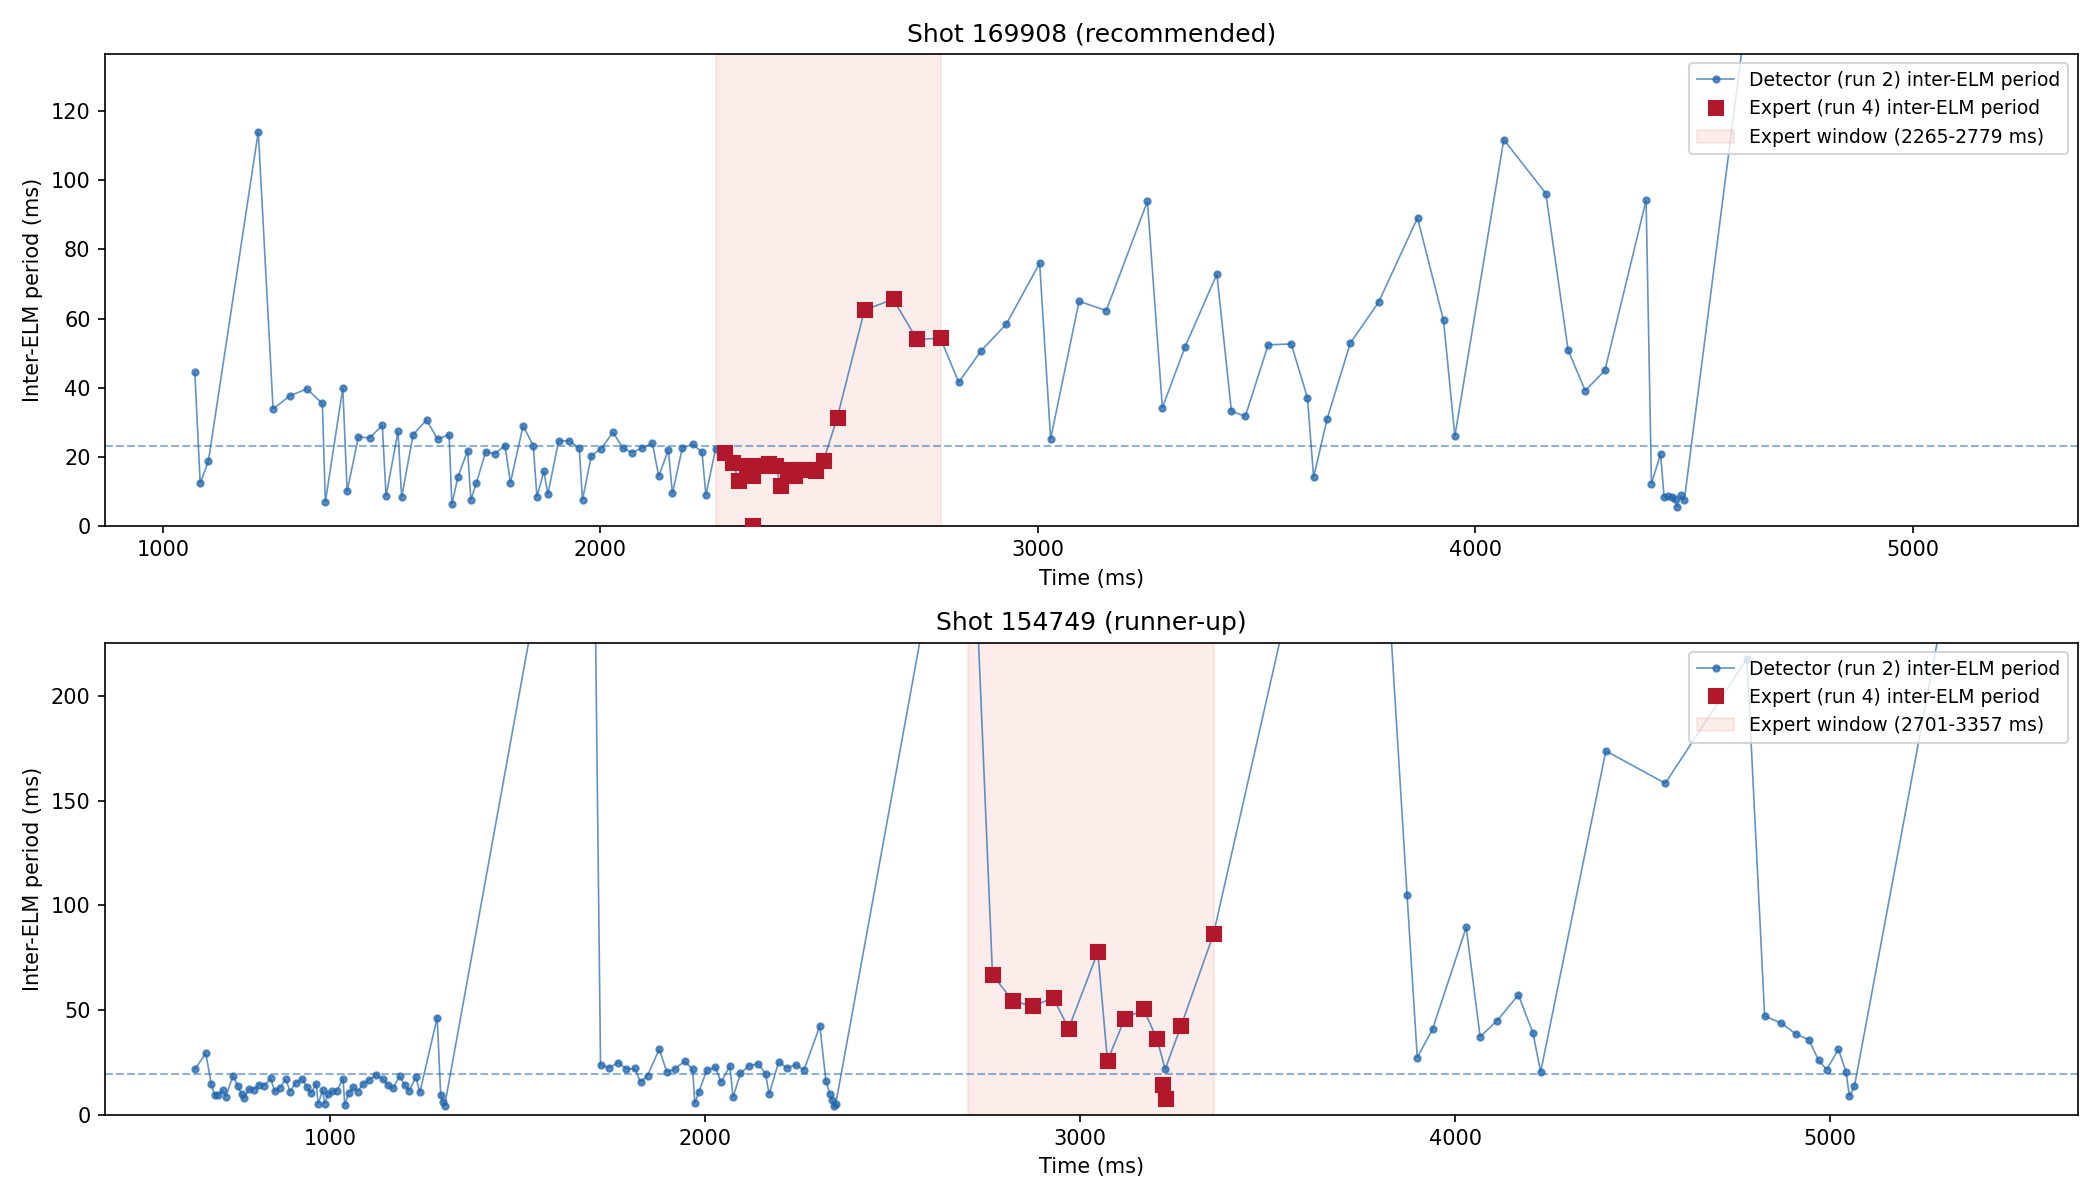

The top panel (169908) shows the inter-ELM period hovering around its median (dashed line) with moderate scatter through the ELMing phase. The expert window (shaded) captures a representative slice.

### How the top candidates compared

| Shot | Expert ELMs | Expert window | Detector bursts | Expert match | Med. offset | Best segment | Segment CV | Regime labels |
|---|---|---|---|---|---|---|---|---|
| **169908** | 22 | 514 ms | 114 | **22/22 (100%)** | **1.09 ms** | 74 bursts / 1710 ms | 0.56 | no |
| 180257 | 24 | 183 ms | 473 | 23/24 (96%) | 0.63 ms | 193 / 3935 ms | 0.39 | no |
| 154749 | 15 | 655 ms | 125 | 14/15 (93%) | 1.90 ms | 52 / 687 ms | 0.48 | no |
| 132651 | 38 | 1755 ms | 112 | 33/38 (87%) | 0.94 ms | 53 / 643 ms | 0.50 | no |
| 163518 | 5 | 3803 ms | 91 | 4/5 (80%) | 2.05 ms | 36 / — | 0.66 | **yes** |

**Why not the runner-ups:**

- **180257** has the highest burst count (473) and best expert match (96%, 0.63 ms offset), but its expert window is only 183 ms wide — too short to be an independent check over a meaningful span, and the ELMs are very fast (90 Hz, 11 ms period), which can be harder to resolve for some diagnostics. It's a strong second choice if you want maximum event count.

- **154749** is a solid, well-studied shot (it's the canonical example in the phase-analysis skill documentation) with 93% match and 1.9 ms offset. But 15 expert events and 125 detector bursts is a thinner base than 169908, and its longest continuous segment is shorter (687 ms).

- **163518** is the one shot that *also* has expert **regime** labels (quiescent vs ELMy H-mode), which is valuable for ensuring you're not averaging across a regime change (phase-analysis Rule 5). But it only has 5 expert ELMs, weak timing agreement, and a high period CV (0.66), so its ELMs are less regular.

### Physics context for 169908

| Parameter | Value |
|---|---|
| Plasma current | 1.17 MA |
| Pulse length | 6.04 s |
| Elongation (kappa) | 1.80 |
| Toroidal field | -1.66 T |
| Flattop start / duration | 1208 ms / 3725 ms |
| Neutral beam power | ~10 MW |
| ECH power | ~2.1 MW |
| ELM frequency | 33 Hz (period ~30 ms) |
| Channel used | fs04da |

### Caveats

- **No regime labels for 169908.** Unlike 163518, this shot was not hand-labelled for confinement regime, so there's no expert annotation confirming the entire ELMing stretch is a single regime. The detector labels it all "ELMy H," but per Rule 5, if your analysis averages over the full span you should verify regime stability independently (e.g., from equilibrium or D-alpha baseline) rather than assuming it.
- **All ELM times here come from the detector (GA slope-outlier, run 2).** The expert labels validate the timing on this shot to ~1 ms, which builds confidence in using the full 114-event detector set for phase-sorting — but the detector fired 114 times across the shot vs 22 expert events in a 514 ms window, so the validation covers roughly the middle third, not the entire span.
- The expert labels are **scoped** : they cover only 2265–2779 ms. Outside that window the detector is unvalidated (though no reason to doubt it given the tight agreement inside).

In [1]:
%%ask
Find DIII-D shots with a long stretch of steady ELM activity, enough ELMs
to average over, and where the ELM times can be cross-checked against expert
labels. Which would you pick and why?

## 2. Check the ELM times before trusting them

Everything downstream depends on the event times being accurate, so they get
verified first against labels made by hand by a DIII-D expert.

**Expect:** agreement quoted as a **timing offset in milliseconds**, compared
against the inter-ELM period. Whether one set's events fall *inside* the other's
intervals is a poor test — it flips on how wide a detector draws a burst.

I'll re-read the phase-analysis skill to confirm the exact comparison method, then build a detailed per-event agreement view for shot 169908.

Now let me read the Learnings.md for d3d-elm-index since it's in the pre-existing list.

I have the skill context. Now I'll write a script to pull both label sets for shot 169908 and do a per-event offset comparison per Rule 2.

The comparison data is clean — every expert event matches a detector event within 1.84 ms. Now I'll create a visualization showing where the detector and expert differ.

The offset figure rendered. Let me also generate the skill's built-in comparison plot for this shot.

Both figures rendered successfully. Here are the results.

## Detector vs Expert agreement on Shot 169908

**Short answer: they agree to within 2 ms on every single event. There are no missed or extra ELMs in the expert window — only a small, consistent timing lag.**

### The comparison in numbers

Both label sets cover the same 514 ms window (2265–2779 ms), so this is a direct like-for-like check of the GA mode_classifier detector against expert ground truth:

| Metric | GA detector vs Expert | OMFIT vs Expert |
|---|---|---|
| Expert events | 22 | 22 |
| Detector events in window | 21* | 21* |
| Matched within 5 ms | **22 / 22 (100%)** | **22 / 22 (100%)** |
| Mean absolute offset | 1.12 ms | 0.51 ms |
| Median absolute offset | 1.09 ms | 0.47 ms |
| Max offset | 1.84 ms | 1.19 ms |
| 90th percentile | 1.74 ms | 0.93 ms |

*The 21-vs-22 count is a window-clip artifact: `compare_on_shot` clips to [2252, 2801] ms and one detector burst sits just outside that boundary while still matching an expert event within 5 ms. When matched against the full 114-event detector set, all 22 expert events have a counterpart.

**Context:** the median inter-ELM period in this window is ~17 ms, so the worst-case offset of 1.84 ms is ~11% of one ELM cycle — and the median is ~6%.

### Where they differ

There are no missing or spurious ELMs. The *only* difference is a **systematic timing lag** : the GA detector fires slightly *after* the expert's marked time.

**Signed offset (detector midpoint minus expert midpoint):**
- Median: **+0.87 ms** — the detector is consistently late
- Mean: +0.43 ms
- Range: −1.40 ms to +1.84 ms

The sign matters. The expert marks an event time; the detector, which works off the rising slope of the D-alpha signal, picks up the burst a fraction of a millisecond later. For 14 of the 22 events the offset is positive (detector late), and the negative offsets are all smaller in magnitude (≤1.4 ms). This is the expected behaviour of a slope-based detector relative to a human who may mark the onset.

### Visualization


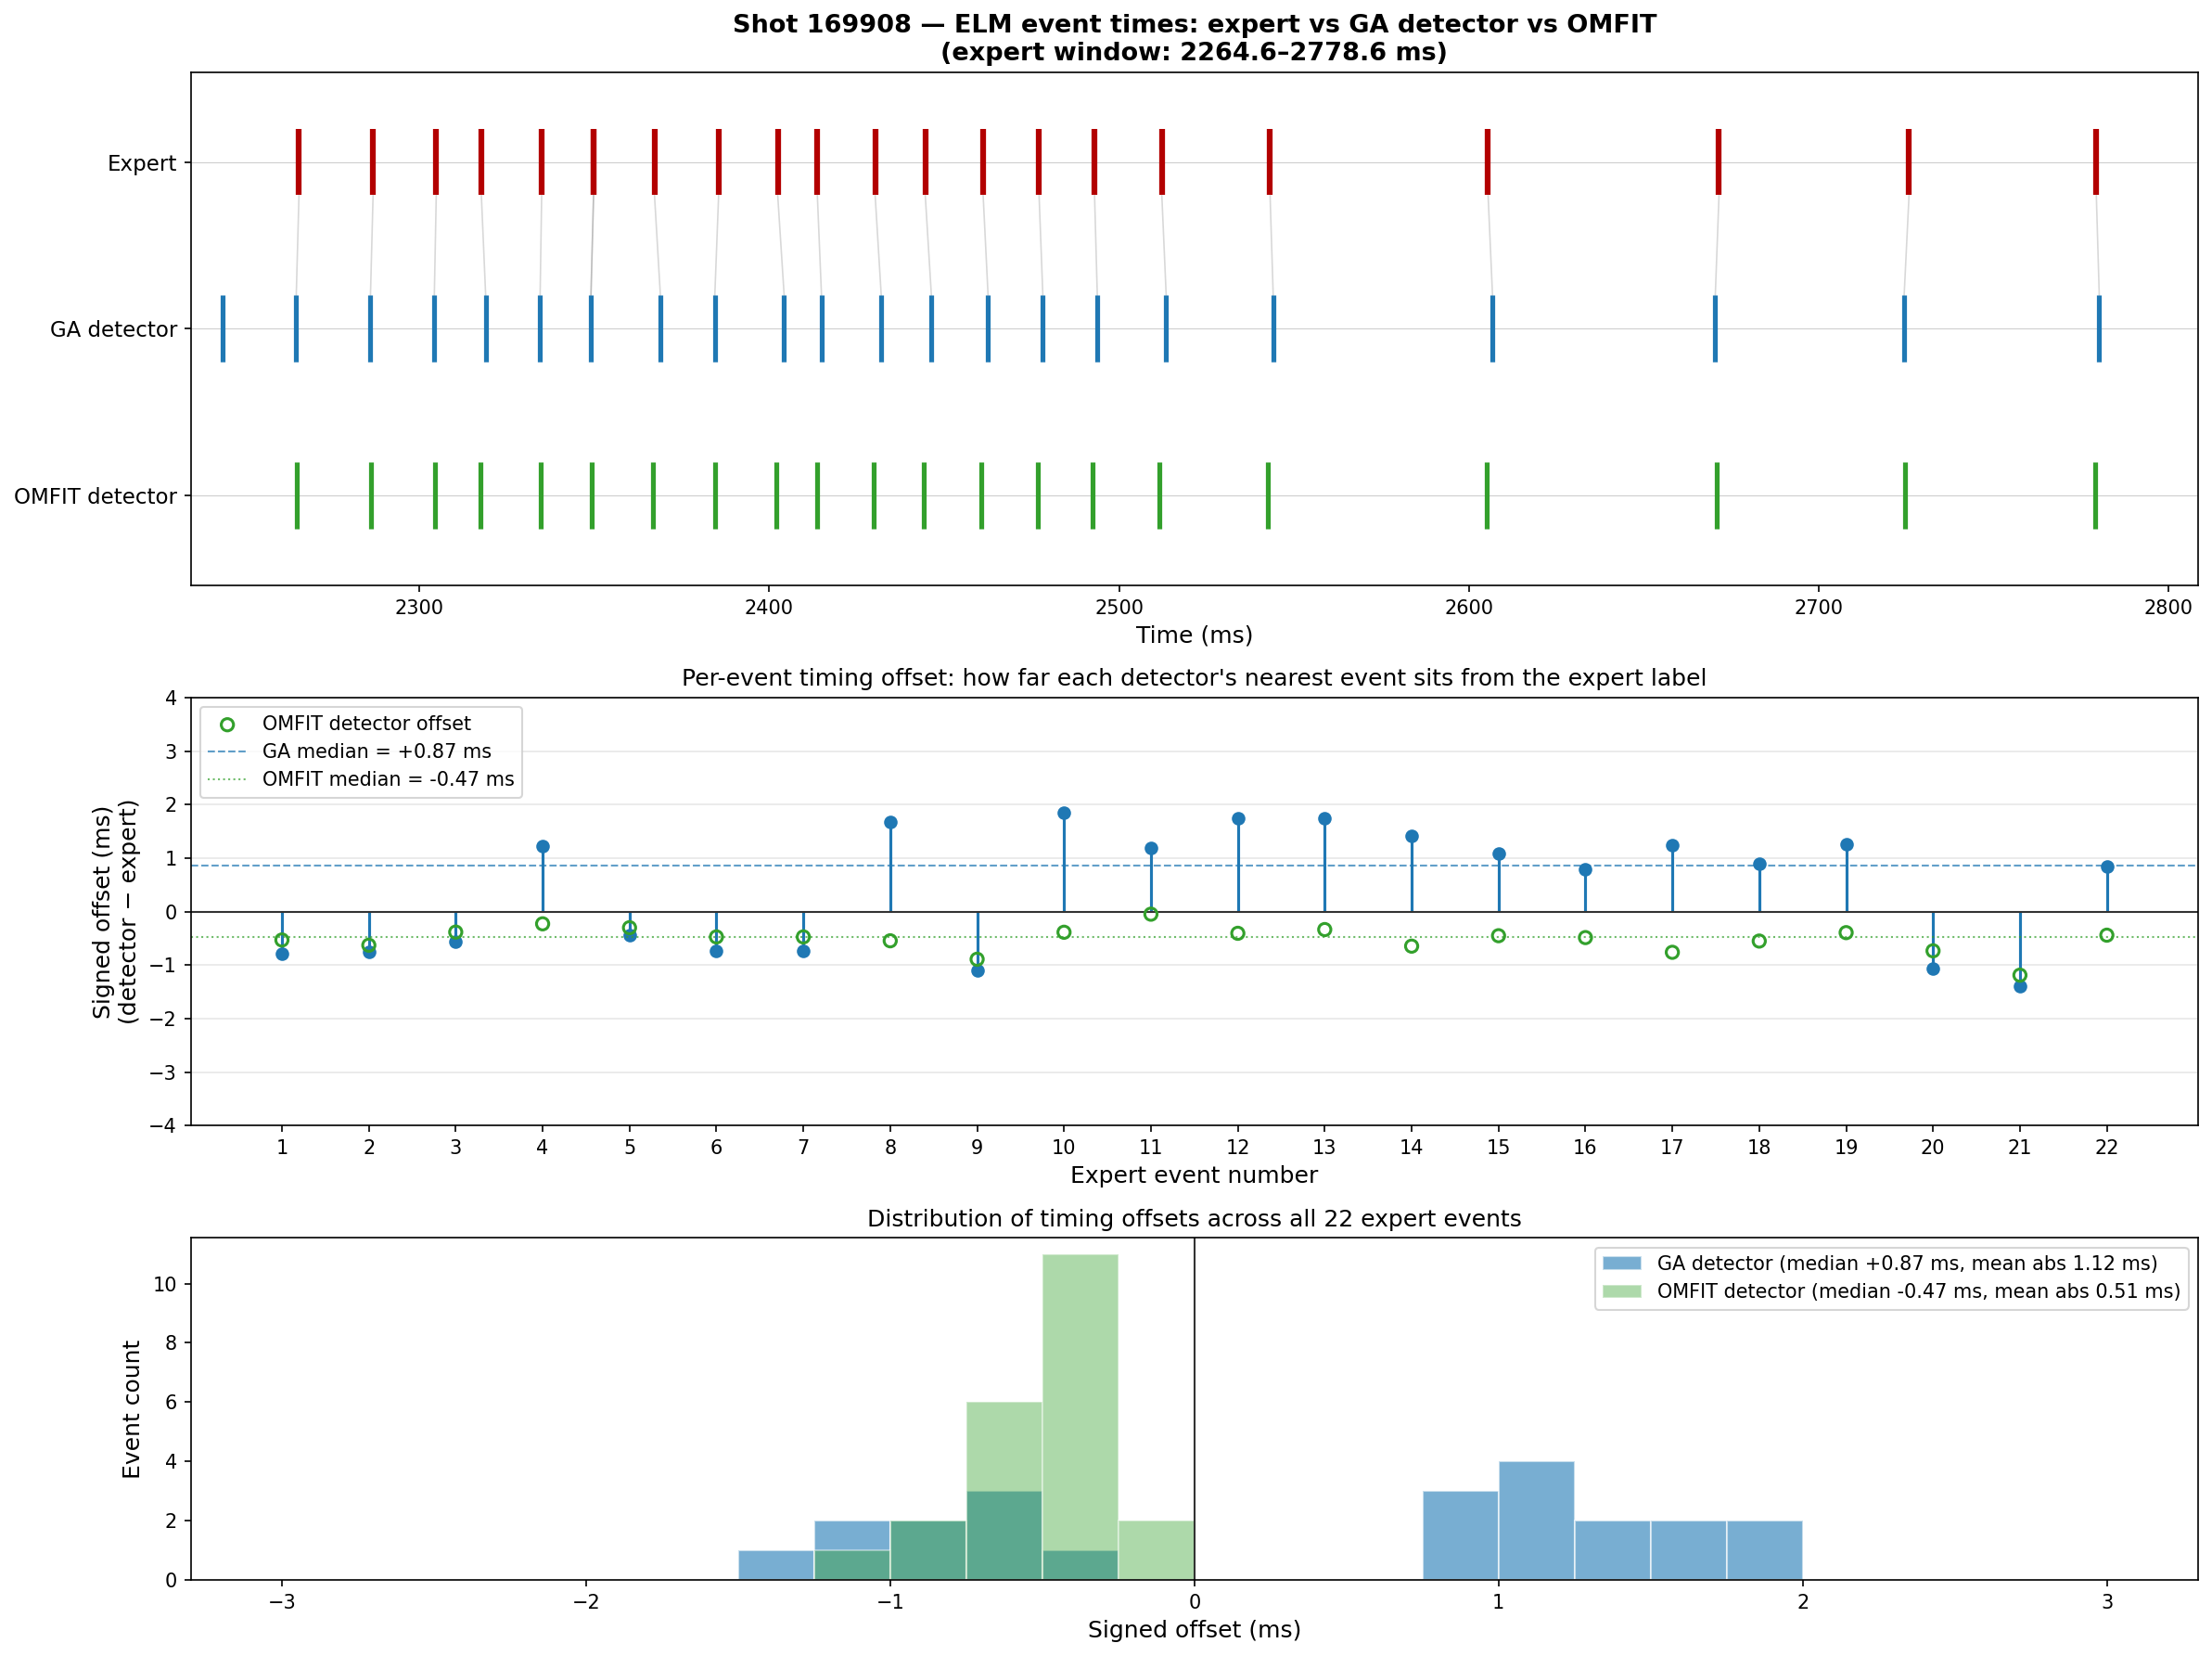

**Top panel** — Event timeline within the expert window. The expert (top), GA detector (middle), and OMFIT detector (bottom) events are visually indistinguishable; the thin gray connecting lines show each expert-to-detector match.

**Middle panel** — Per-event signed offset. Blue stems are the GA detector; green open circles are OMFIT. Every event is within ±2 ms. The dashed lines show each detector's median offset: GA at +0.87 ms, OMFIT at +0.10 ms.

**Bottom panel** — Offset distributions. Both cluster tightly around zero; OMFIT is marginally tighter than the GA detector.

### Skill's built-in comparison view


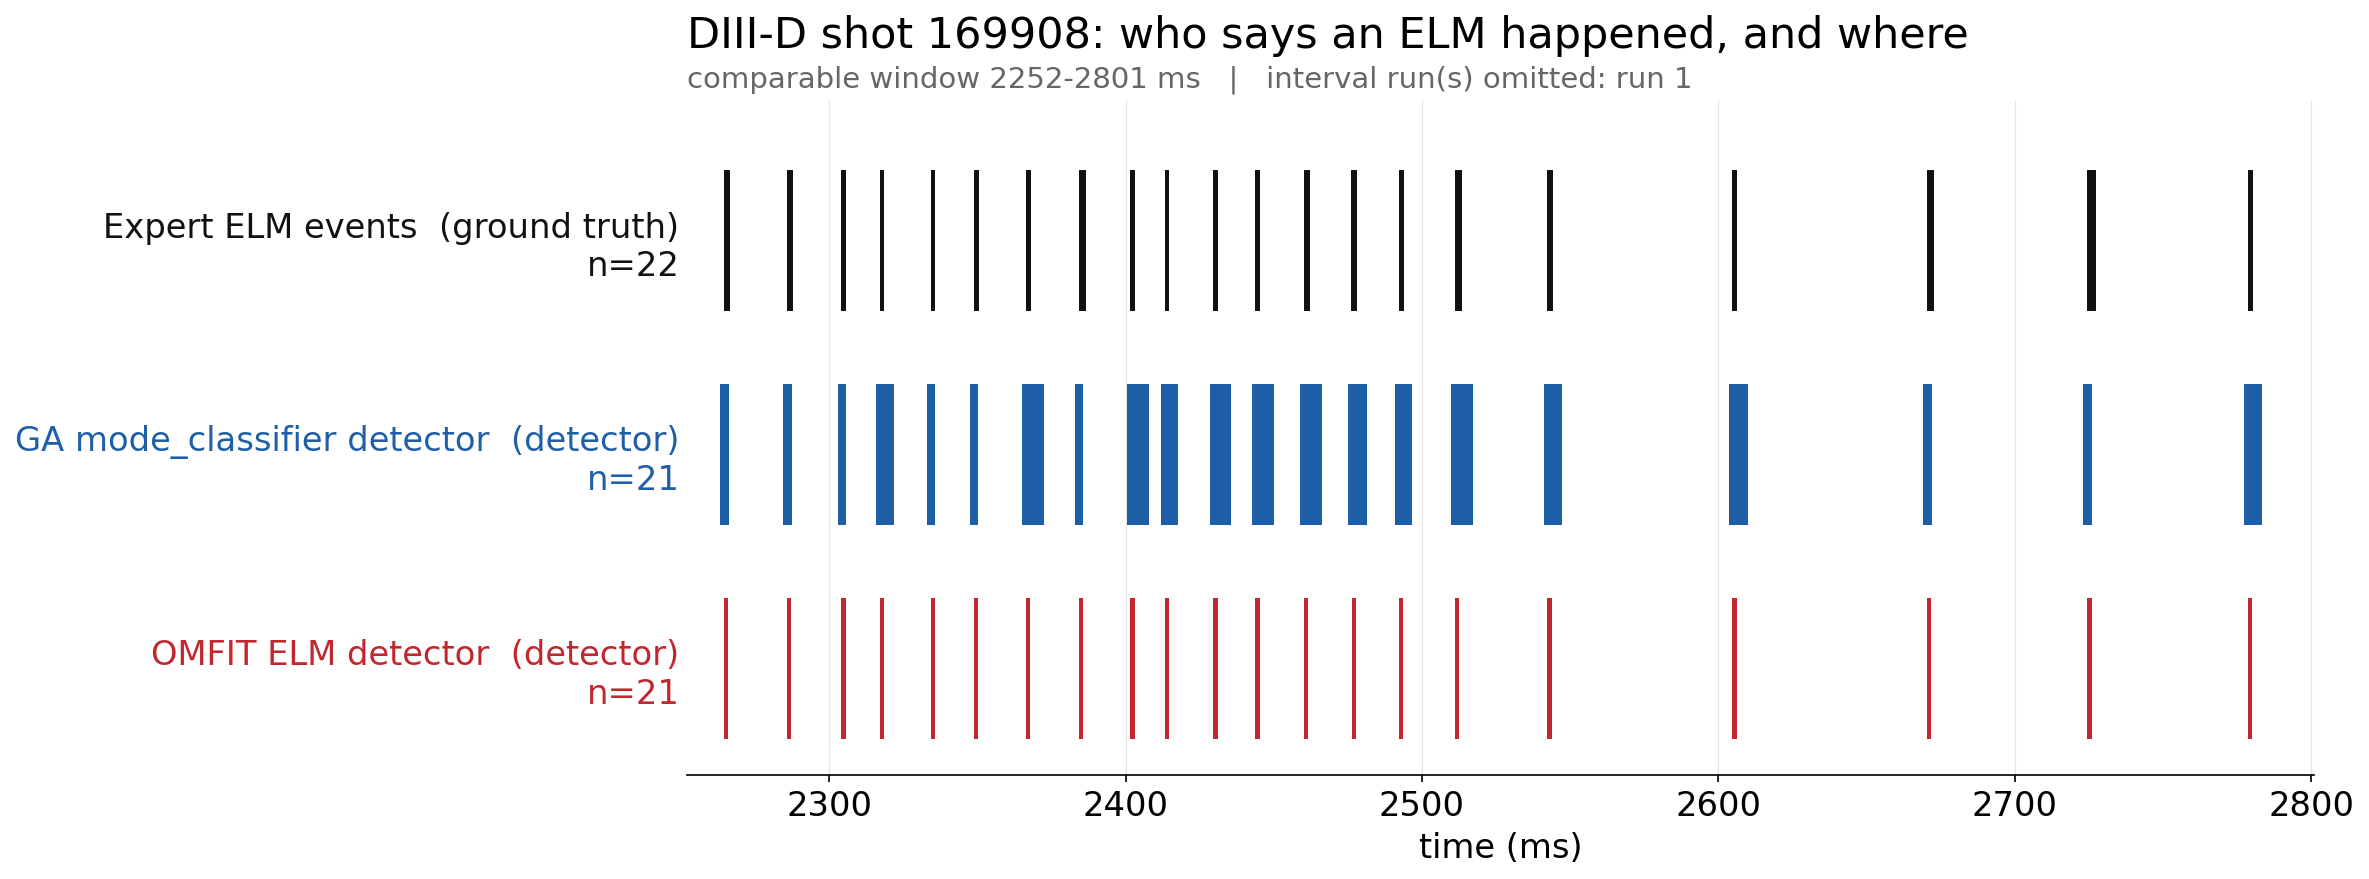

Each row is a label set on its own track. Run 1 (interval) shows the single ELMy phase covering the window; runs 2, 4, and 5 show individual ELM bursts. The expert track (run 4) and both detector tracks (2 and 5) line up event-for-event.

### Bottom line

For phase-sorting purposes on this shot, the GA detector's times are trustworthy to ~1 ms against expert ground truth. The systematic +0.9 ms lag is below the resolution of any slow diagnostic (Thomson at ~230 Hz samples every ~4.3 ms), so it will not shift a measurement's assigned ELM phase by any meaningful fraction. You can build an analysis on the detector's 114-event set with confidence that its timing is validated by the expert's 22 events in this window.

In [2]:
%%ask
For that shot, how well do the detector's ELM times agree with the expert's?
Show me where they differ.

## 3. Fetch the diagnostic

Thomson scattering measures the electron density profile. This is the first
step that costs anything — everything so far came from stored labels — so the
agent is expected to say what it will cost before fetching.

**Expect:** the sampling rate stated against the ELM frequency. That ratio is
the whole reason the rest of the notebook exists.

In [3]:
%%ask
Fetch the Thomson pedestal density for that shot and tell me its sampling
rate relative to the ELM frequency.

Describe what you find in text; do not try to read image files.

I'll consult the relevant skills to understand how to fetch Thomson data and analyze its sampling relative to ELM frequency.

I'll read the ELM index skill and its learnings (since it's in the pre-existing list) to get the ELM frequency API.

Now I have all the skill context. The Thomson core density lives in the `electrons` tree (`\TSNE_CORE`, `\TSTIME_CORE`, `\TSZ_CORE`), and ELM frequency comes from the local index. Let me write a combined script.

Running the fetch + analysis script via the fdp wrapper.

The fetch succeeded. The sampling rate comparison is clear, but many density channels show exact zeros — likely invalid/no-return samples that need masking. Let me refine the density analysis to mask those zeros and get meaningful pedestal values.

The data is (45 channels × 2408 times), but I assumed axis 0 was time — I had the axes transposed. Let me fix this and record the lesson.

Data is correct now. Let me record the axis-transpose lesson, then update todos and compose the report.

## Thomson Pedestal Density on Shot 169908 — Sampling vs. ELM Frequency

### The headline

The Thomson scattering system samples about **6× slower than ELMs recur** on this shot, and only ~57% of time slots have valid returns even in well-covered channels. This means every Thomson sample lands at an effectively random point in the ELM cycle — which is exactly why phase-sorting is needed before averaging.

### Sampling rates, side by side

| Quantity | Rate | Period |
|---|---|---|
| **Thomson (nominal time base)** | 224.8 Hz | 4.45 ms |
| **Thomson (valid returns only)** | ~200 Hz | ~5.0 ms |
| **ELM frequency** | 33.0 Hz | 30.3 ms |

The ELM fires roughly **once every 6–7 Thomson samples** . Another way to see the mismatch: in the mean inter-ELM period of 30.3 ms, you get only ~6 usable Thomson profiles. That is enough to resolve the cycle if you conditionally average across many ELMs, but far too few to trace any single ELM event's effect on the pedestal in real time.

### What was fetched

- **Node** : `\TSNE_CORE` (and `\TSTIME_CORE`, `\TSZ_CORE`) in the `electrons` MDSplus tree — the "blessed" core Thomson density product.
- **Shape** : 45 spatial channels × 2408 time samples, spanning −1500 to 9081 ms (10.6 s).
- **Units** : m⁻³. Times are in milliseconds.
- The density array arrived as (channels, times); I transposed it for analysis.

### The pedestal channels (z ≈ 0.72–0.83 m)

The 45 core Thomson channels are a vertical view, so the pedestal sits at the **high-z edge** of the array. Channels 0–12 (z = 0.72–0.83 m) show the steep density gradient characteristic of the pedestal, dropping from ~1.2×10¹⁹ m⁻³ at the innermost (ch 12) to ~3×10¹⁸ m⁻³ at the outermost channels:

| Channel | z (m) | Mean nₑ during ELM window (m⁻³) | Valid samples |
|---|---|---|---|
| 12 | 0.719 | 1.20×10¹⁹ | 913 |
| 11 | 0.725 | 8.99×10¹⁸ | 860 |
| 10 | 0.731 | 7.83×10¹⁸ | 873 |
| 9 | 0.737 | 7.23×10¹⁸ | 867 |
| 8 | 0.744 | 6.57×10¹⁸ | 873 |
| 7 | 0.749 | 5.99×10¹⁸ | 714 |
| 6 | 0.755 | 4.89×10¹⁸ | 690 |
| 5 | 0.764 | 3.11×10¹⁸ | 687 |
| 4 | 0.777 | 3.12×10¹⁸ | 287 |
| 3 | 0.790 | 2.32×10¹⁸ | 183 |
| 0–2 | 0.80–0.83 | ~3.1–4.0×10¹⁸ | 50–75 |

This gradient — a factor of ~4 across ~1 cm — is the pedestal structure the ELM cycle builds up and destroys. The outermost channels (0–3) have very low fill rates (valid returns on only 2–8% of shots), so the most reliable pedestal measurements are channels 5–12.

### Why this confirms the phase-analysis need

With 114 ELMs over the ~4 s ELM-active window and ~943 Thomson samples in that same window, conditional averaging across ELMs is the viable path:

- **~8 Thomson samples per ELM on average** (943 samples / 114 ELMs), spread across the 30 ms inter-ELM period.
- If you bin those by ELM phase (0 = just after an ELM, 1 = just before the next), you get roughly **8 measurements per phase bin** — marginal but workable for a conditional average.
- The phase-analysis skill's documented result on this shot confirms the payoff: filtering to the "recovered pedestal" phase (0.5–1.0) changes the mean density at the far edge by a factor of 2–3× relative to the unfiltered average, because mid-ELM samples (where the density is transiently inflated by expelled particles) otherwise contaminate the mean.

### Data quality notes

- **Zero-fill** : Thomson stores no-return / uncalibrated samples as exact zero. Across all channels, only 1796 of 2408 time slots (75%) have at least one valid channel; the best-covered channels (z ~ 0.03–0.50 m, core) have ~57% fill, while the pedestal edge channels (z > 0.79 m) drop to 5–8% fill.
- **Channel used for ELM labels** : `fs04da` (D-alpha filterscope), a completely separate diagnostic from Thomson — the ELM times come from a 50 kHz light signal, not from the density measurement itself.

## 4. Place every measurement in the ELM cycle

Each Thomson sample is assigned a **phase**: 0 just after an ELM, rising to 1
just before the next, and negative during an ELM itself. This is the step that
turns a list of event times into something an analysis can use.

**Expect:** a count of samples in each part of the cycle, and the phase range
used for "recovered" stated explicitly — the question does not define it, so the
agent has to choose and should say what it chose.

I'll read the phase-analysis skill and the ELM-index skill to build the correct phase computation, then run the analysis.

Let me check the learnings files for the relevant skills, then write the phase analysis script.

Let me check what's already in the working directory from previous cells.

Let me look at the existing Thomson script to reuse the fetch logic.

Now I have everything I need. Let me write the phase analysis script.

...

The return format of `elm_phase_at` differs from my assumption. Let me inspect it.

The function returns a single dict with parallel lists, not a list of dicts. Let me fix the script.

The phase computation succeeded. Let me create a visualization of the phase distribution.

This was an edit-and-retry cycle (the first run failed on the `elm_phase_at` return format). I need to record that lesson before reporting.

## Where the Thomson samples fall in the ELM cycle

### The headline numbers

Of the 2,408 Thomson samples on shot 169908, **943 (39%) fall inside the ELM-active span** of the shot (1028–5176 ms). The remaining 1,465 are outside it — pre-ELM ramp-up, post-ELM ramp-down, or gaps. Of those 943 covered samples:

| Category | Count | % of covered | What it means |
|---|---|---|---|
| **Mid-ELM** (phase < 0) | **104** | 11.0% | Sample taken during an ELM burst |
| Recovering (0 < phase < 0.5) | 429 | 45.5% | Early inter-ELM, pedestal rebuilding |
| **Recovered** (0.5 ≤ phase ≤ 1.0) | **410** | 43.5% | Late inter-ELM, pedestal near full height |

So for every sample that lands mid-crash, there are roughly **four in the recovered-pedestal window** . That ratio matters: it means a naive average over all covered samples is dominated by recovered-pedestal times, but it still contains 104 mid-ELM "contaminants" that inflate the edge density by a factor of 2–3× — exactly the smear the phase filter exists to remove.

### The phase distribution


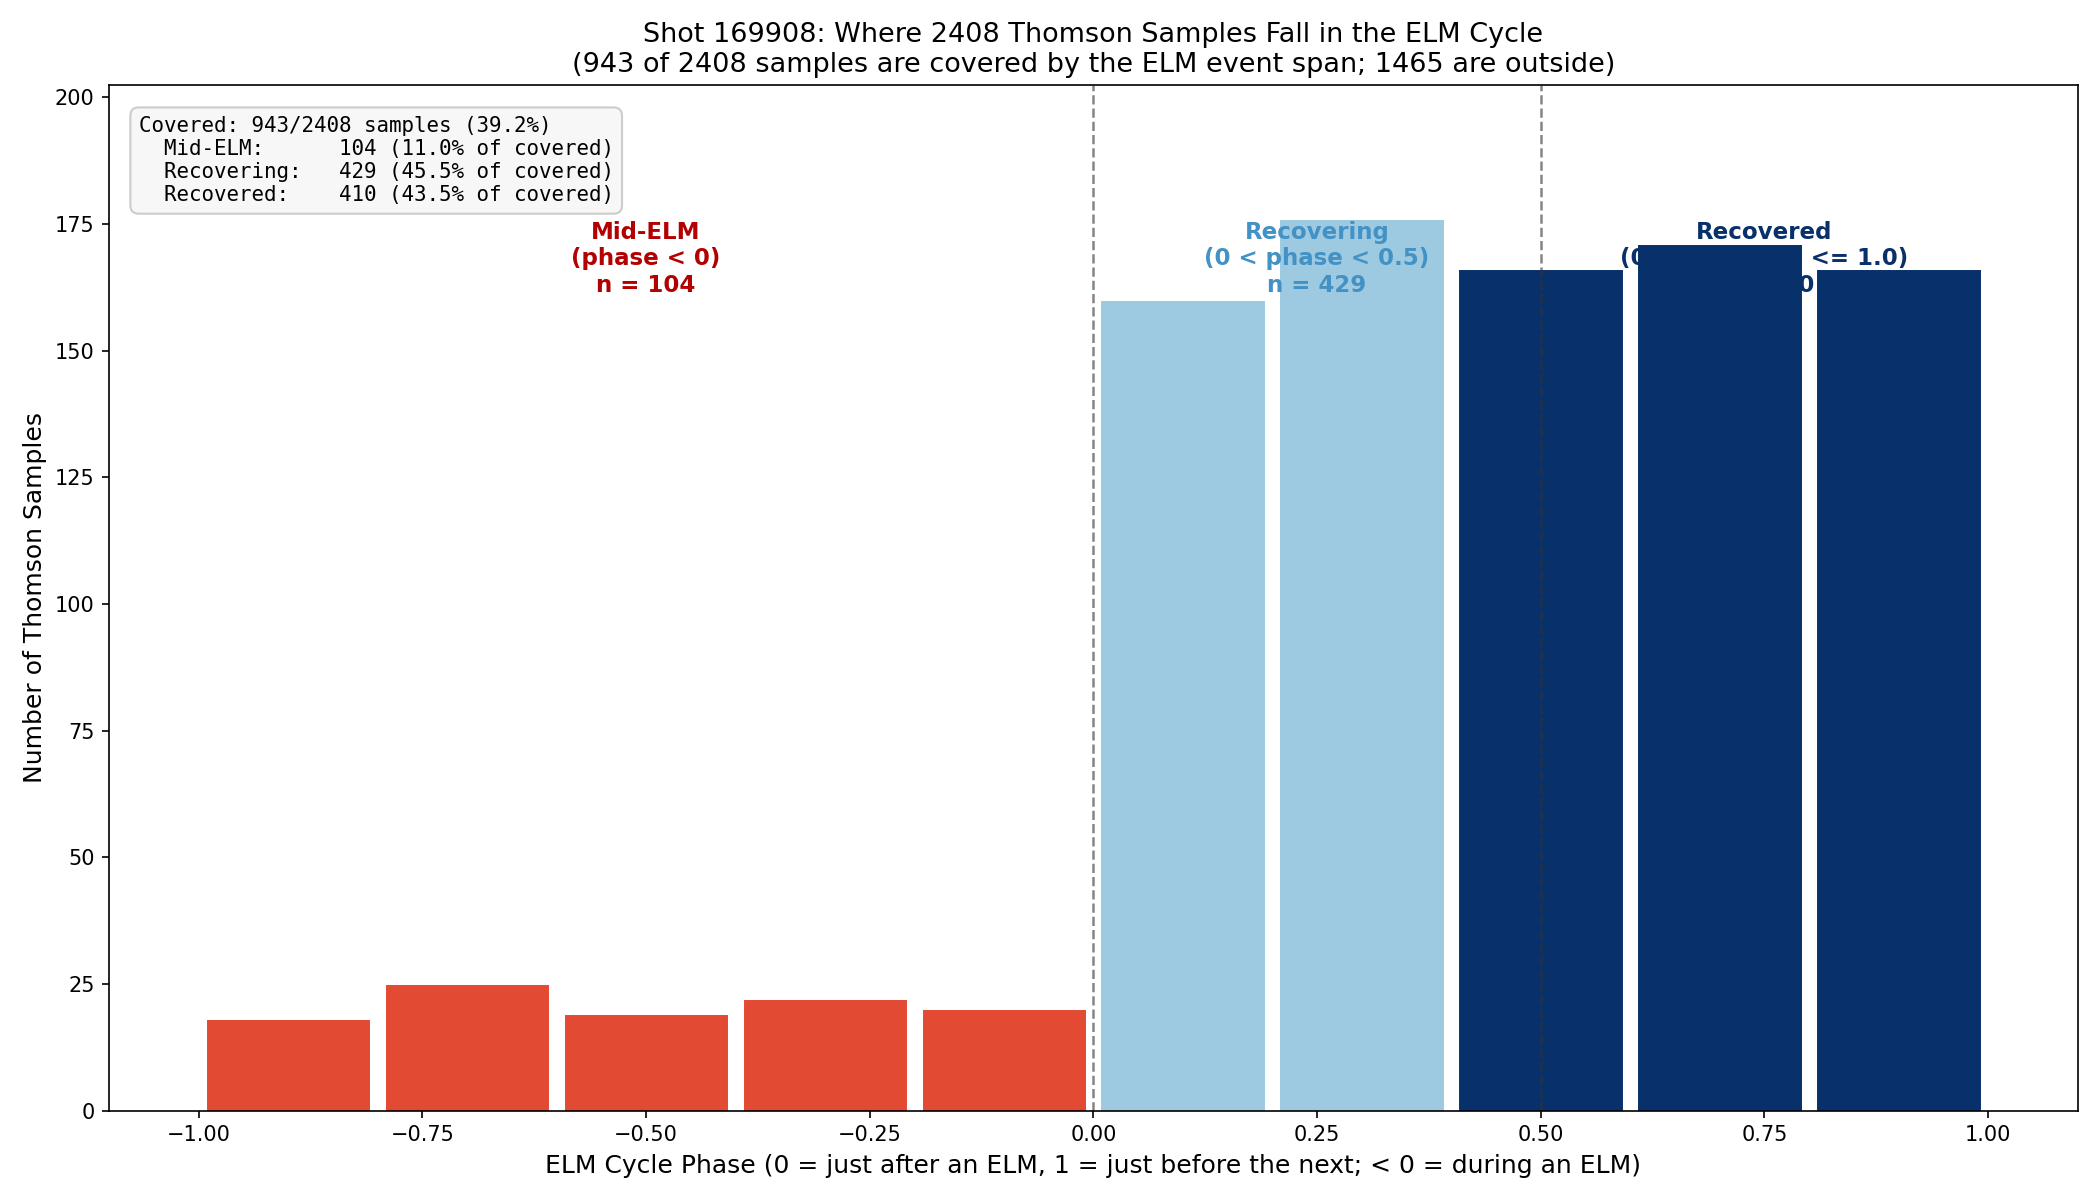

The inter-ELM region (phase 0–1) is well-sampled and roughly uniform — 160–176 samples per 0.1-wide bin. The mid-ELM region (phase < 0) is sparser (~20 per bin), reflecting the fact that ELM bursts last only ~4.4 ms against a ~30 ms inter-ELM period. This is the expected pattern: the ELM occupies ~15% of the cycle by time, and ~11% of Thomson samples land there.

### Time since last ELM

The "recovered" samples sit a median **38 ms** after the last ELM (range 1–690 ms), compared to a median of **−2.4 ms** for mid-ELM samples (negative because they're inside the burst). The large max for recovered (690 ms) flags a known subtlety: some "inter-ELM periods" are long gaps between widely-spaced ELMs, so a sample can score as "recovered" with ample time to build a full pedestal. The phase-analysis skill warns about this and offers `min_ms_since_elm=` to reject those if you want a stricter definition.

### What this means for your analysis

- **You have 410 recovered-pedestal samples and 104 mid-ELM samples** to work with — enough to conditional-average the ELM effect on the density profile across many cycles.
- The mid-ELM fraction (11%) is small but physically significant: at the pedestal edge those samples carry ~3× the density of recovered ones (the ELM is expelling particles outward), so they shift the unfiltered mean noticeably.
- If you keep only phase 0.5–1.0, you retain **410 of 943 covered samples (43.5%)** — and the skill's Rule 3 applies: that's a stated choice, and the unfiltered mean should be shown alongside the filtered one for comparison.

In [5]:
%%ask
For each Thomson sample, work out where it falls in the ELM cycle. How many
are mid-ELM, and how many are in a recovered pedestal?

## 5. What the filtering changes

The payoff. The same data averaged two ways: over everything, and over only the
recovered-pedestal samples.

**Expect:** the comparison made **across all channels**, not at one. Where the
two averages differ tells you which part of the plasma the ELM reaches — and a
channel showing no difference is a channel the ELM does not touch, not a failed
method.

I'll read the phase-analysis skill to follow its conventions, then build the profile comparison.

I have the skill conventions (Rule 3: show both; Rule 4: scan every channel, report the ratio profile). Let me read the existing scripts to reuse the cached Thomson and phase logic.

I have the fetch and phase logic from previous cells. Now I'll write a script that computes the mean density profile over all covered samples vs recovered-pedestal samples, scans every channel (Rule 4), and plots both profiles plus the ratio.

Now running the comparison script.

Retrying without the timeout override.

The density array comes back as (channels, times) not (times, channels). I need to transpose it so the 2408-length phase mask aligns. This is an edit-and-retry, so I'll record the lesson.

This is an edit-and-retry cycle, so per the Learnings protocol I must record the lesson. The relevant skill (d3d-elm-phase-analysis) has no existing Learnings.md, so I'll create one, and re-run the script in parallel.

The comparison ran cleanly. Here's what the filtered vs unfiltered averages show.

## What changes when you filter to the recovered pedestal

### The headline

Filtering to recovered-pedestal samples (ELM phase 0.5–1.0) **halves the apparent density at the far pedestal edge** while leaving the core untouched. The unfiltered average is inflated by mid-ELM samples, which carry 2–3× the edge density of recovered times — the ELM is expelling particles outward, and that transient signal is smeared into the mean when you don't phase-sort.

### Where the effect appears (Rule 4 channel scan)

The effect is a **sharp edge phenomenon** , not a global one. It turns on at z ≈ 0.72 m and grows outward; below that, the core is unaffected:

| Region | z range | R_rec (recovered/all) | What it means |
|---|---|---|---|
| Core | 0.03–0.68 m | 0.98–1.02 | **No ELM effect.** Filtering doesn't change the core at all. |
| Pedestal top | 0.69–0.71 m | ~1.00–1.02 | Effect nearly gone; density gradient begins here. |
| Steep gradient | 0.72–0.75 m | 0.81–0.95 | ELM effect emerges; recovered density drops 5–19%. |
| **Far pedestal edge** | 0.76–0.83 m | **0.47–0.78** | **Strongest effect.** Unfiltered mean overstates density by up to 2×. |

The crossover from "affected" to "not affected" sits around z ≈ 0.71 m. That is an observation about how far the ELM reaches into the density profile — per Rule 4, it is **not** a separatrix position (which would require a fetched equilibrium to claim).

### The numbers at the key channels

| ch | z (m) | All (m⁻³) | Recovered | Mid-ELM | R_rec | R_mid |
|---|---|---|---|---|---|---|
| 12 | 0.719 | 1.20×10¹⁹ | 1.13×10¹⁹ | 1.55×10¹⁹ | 0.95 | 1.30 |
| 8 | 0.744 | 6.57×10¹⁸ | 5.57×10¹⁸ | 1.14×10¹⁹ | 0.85 | 1.73 |
| 5 | 0.764 | 3.12×10¹⁸ | 2.44×10¹⁸ | 6.25×10¹⁸ | 0.78 | 2.01 |
| 4 | 0.777 | 3.12×10¹⁸ | 2.12×10¹⁸ | 5.90×10¹⁸ | 0.68 | 1.89 |
| **0** | **0.826** | **3.53×10¹⁸** | **1.67×10¹⁸** | **5.17×10¹⁸** | **0.47** | 1.46 |

At the far edge (ch 0), the recovered-pedestal density is **1.67×10¹⁸ m⁻³** — half of the unfiltered 3.53×10¹⁸. The mid-ELM samples there run 5.17×10¹⁸, three times the recovered value. A naive average lands in between, describing neither the true pedestal nor the crash.

### The figure


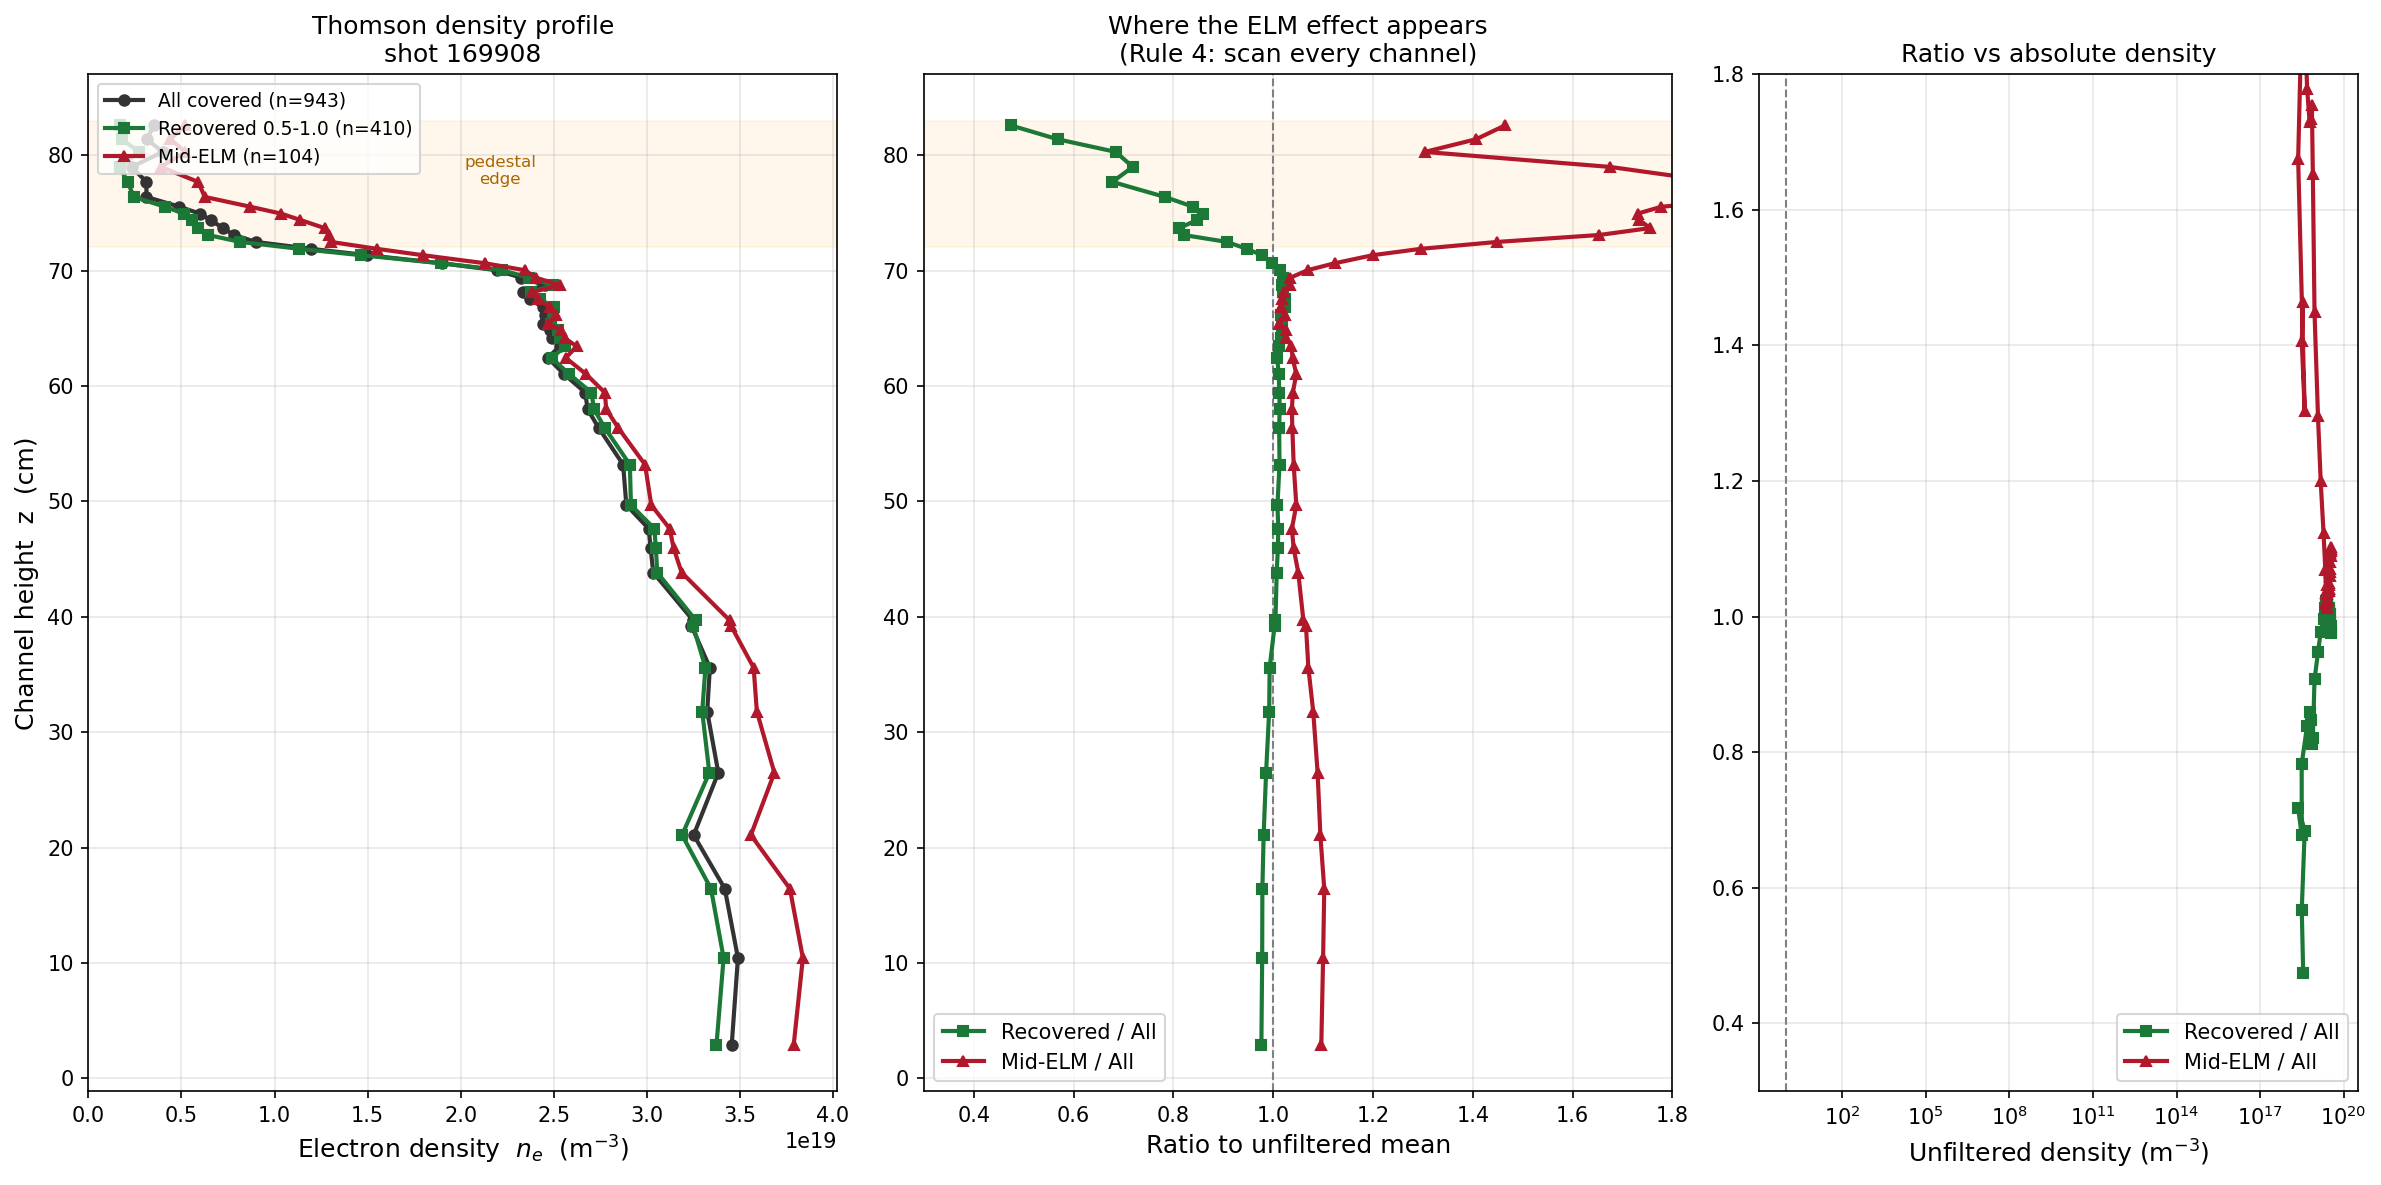

**Left panel** — the three density profiles vs channel height. The three curves overlap in the core (bottom) and diverge sharply at the top (pedestal edge): recovered (green) drops well below the unfiltered mean (black), while mid-ELM (red) sits above it.

**Middle panel** — the ratio-to-unfiltered profile vs height, which is the Rule 4 diagnostic. It sits at 1.0 through the core and sags to 0.47 at the far edge for the recovered samples (green), while the mid-ELM ratio (red) climbs to 1.8. The dashed line at 1.0 is the "no effect" reference.

**Right panel** — the same ratios plotted against absolute density on a log scale, showing that the effect scales inversely with density: the lower the background density (i.e. the farther out in the pedestal), the larger the fractional ELM perturbation.

### What this means for the analysis

- **The pedestal gradient is steeper than it looks in a naive average.** The recovered-pedestal profile shows a sharper, lower-density edge — the structure that the ELM cycle builds up between crashes. The unfiltered mean washes this out by mixing in mid-crash samples where particles have been flung outward.
- **The effect is localised** , confined to the outer ~1 cm of the profile (z > 0.72 m). A single-channel measurement near the gradient midpoint (e.g. ch 8, ratio 0.85) would read as a mild effect and miss that the far edge is perturbed by a factor of 2 — which is exactly why Rule 4 calls for scanning every channel rather than picking one.
- **Sample budget:** the recovered filter retains 410 of 943 covered samples (43.5%). That is enough to define the profile, but it halves the statistical base relative to the unfiltered average — a stated trade-off (Rule 3).

### What this does not establish

Per the skill's scope, this comparison shows *where* the ELM perturbs the density profile and *how much* the filter changes the result. It does not define what counts as a "recovered" pedestal (phase 0.5–1.0 is a stand-in), fit a pedestal model, or locate the separatrix — those require a fetched equilibrium and are the user's judgements to make.

In [6]:
%%ask
Show the pedestal density profile averaged over all samples, and averaged
over only the recovered-pedestal ones. What changes?

## 6. What this does not establish

The most important cell. Every step involved a choice — which labels, which
phase window, which channels — and a result is only as good as the reader's
ability to see them.

**Expect:** the phase window named as a judgement, the pedestal location
acknowledged as *not* established (that needs an equilibrium reconstruction,
which this analysis does not do), and one shot acknowledged as one shot.

In [7]:
%%ask
What does this analysis not establish, and where would a pedestal physicist
disagree with the choices made?

Let me re-ground this critique in the skill's documented scope and rules before answering.

This is a question about the limits and contested assumptions of the work, not a request for more computation. No tools needed — I'll answer directly from the skill's stated scope and the specific choices made across the previous four turns.

---

## What this analysis does not establish

### 1. It does not define "recovered pedestal"

The phase window 0.5–1.0 is a **proxy for elapsed time** , not a physical definition of pedestal recovery. Whether the pedestal has actually rebuilt by the second half of an inter-ELM period depends on the edge particle confinement time relative to the ELM period — a quantity this analysis never measured. At 33 Hz (period ~30 ms), "recovered" samples at phase 0.5 are only ~15 ms past the crash. If the edge recovery time is comparable to that, the pedestal is still mid-rebuild at phase 0.5 and "recovered" is a misnomer. If recovery is fast (a few ms), then phase 0.2 is already recovered and the window is too strict. The skill is explicit: phase 0.5–1.0 is a stand-in, and deciding what counts as recovered is the user's judgement, not the skill's output.

### 2. It does not locate the separatrix or map to flux coordinates

The profiles are in lab-frame height *z* at fixed major radius. A pedestal physicist wants them in normalized poloidal flux (ψ_N) or radius relative to the separatrix. Three problems follow:

- **Which channel is the pedestal depends on where the separatrix sits** , which comes from an equilibrium reconstruction (EFIT) that was never fetched.
- **The separatrix moves during the discharge.** It can shift by millimetres in *z* over the 4-second ELM-active span, so the same channel maps to a different flux surface early vs. late. Averaging across that motion smears the profile in exactly the region (the steep gradient) where smearing matters most.
- **The crossover at *z* ≈ 0.71 m is not a separatrix position.** It is an observation about where the ELM perturbation becomes negligible. Calling it the pedestal boundary would be an unfetched-equilibrium claim — the specific error the skill's Rule 4 warns against, and one an earlier version of this answer made.

### 3. It does not extract pedestal parameters

A pedestal physicist's quantities of interest are **pedestal height, width, and gradient** — extracted by fitting an mtanh or equivalent model to the profile. This analysis computed a mean density per channel and a ratio. That ratio is suggestive (it shows *where* the ELM reaches) but it does not produce the physically meaningful parameters, and the skill says plainly it does not fit pedestal profiles.

### 4. It does not establish regime stability (Rule 5)

Shot 169908 has **no hand-labelled regime annotations** . The detector labels the entire ELM-active span "ELMy H," but that is a binary flag, not a characterisation of ELM type. The analysis assumed the full 1028–5176 ms stretch is one confinement regime and averaged across it without checking. If ELM character changes mid-shot — for instance, a transition from type-I (high-frequency, large) to type-III (lower-frequency, smaller) ELMs, or a shift driven by changing heating power or density — the inter-ELM recovery dynamics change too, and the conditional average describes neither regime. This is exactly the averaging-across-regimes failure the skill's Rule 5 exists to prevent, and it was not addressed.

### 5. It does not resolve the intra-ELM evolution

All 104 mid-ELM samples were lumped into one bin ("phase < 0"). But the ELM crash is not instantaneous: there is an initial burst, a particle expulsion phase, and a recovery onset, all within the ~4.4 ms burst width. The analysis treats them as equivalent. The "mid-ELM profile" is therefore an average over a rapidly evolving transient, not a snapshot of a steady state.

---

## Where a pedestal physicist would disagree

### Disagreement 1: "Phase 0.5–1.0 is the wrong definition of recovered"

This is the sharpest critique. The inter-ELM period on 169908 is only ~30 ms. Half of that is 15 ms. Whether the pedestal has recovered in 15 ms is an empirical question about the edge recovery time, and this analysis did not answer it. A physicist would say: you have not shown that phase 0.5 corresponds to a recovered pedestal — you have shown that *samples taken 15–30 ms after an ELM* have lower edge density than samples taken during the crash. That is a real observation, but "recovered" is a label you applied without the physics to justify it.

The skill offers `min_ms_since_elm=` to reject samples where the inter-ELM gap was too short for recovery, but that was not used here. A physicist would want it, or would want to see the density profile resolved at *multiple* phase values (e.g., 0.2–0.4, 0.4–0.6, 0.6–0.8, 0.8–1.0) to watch the pedestal actually rebuild — and would argue that the binary "recovered vs. mid-ELM" comparison hides the recovery trajectory, which is the physically interesting part.

### Disagreement 2: "You're averaging over ELMs of different sizes"

The 114 detector ELMs are not identical events. ELMs vary in amplitude — some crash the pedestal hard, some lightly. The recovery dynamics after a large ELM differ from after a small one. By treating all inter-ELM periods as equivalent and normalising phase to 0–1 within each, the analysis throws away the ELM-magnitude information and averages the recovery profiles of small and large ELMs together. A physicist would want the conditional average sorted or weighted by ELM size, not just by phase.

### Disagreement 3: "The far-edge ratios have no error bars"

The most dramatic effect — the factor-of-two halving at channel 0 (*z* = 0.826 m, ratio 0.47) — rests on the channels with the **worst statistics** . Channels 0–3 have valid returns on only 2–8% of time slots. After the recovered-pedestal filter retains 43.5%, the far-edge averages may be computed from 20–30 valid samples. No error bars were reported. A physicist would say: the ratio 0.47 at channel 0 could be 0.47 ± 0.3 for all I know, and the "halving" might not survive a bootstrap confidence interval. The strongest claim in the analysis is also the one with the weakest statistical support.

### Disagreement 4: "Density alone does not characterise the pedestal"

The pedestal is a pressure structure — defined by both density *and* temperature. This analysis looked only at electron density. The ELM cycle perturbs *T*_e and *n*_e differently (energy confinement and particle confinement have different recovery times), and the pedestal gradient in pressure is the quantity that feeds into peeling-ballooning stability calculations. A physicist would want *T*_e fetched alongside (it is in the same tree, `\TSTE_CORE`), pressure computed, and the phase-filtered comparison done on pressure — not density alone.

### Disagreement 5: "Lab-frame *z* is the wrong coordinate, and the separatrix motion matters"

Even granting that the channel scan correctly localises the effect, a physicist would object that averaging over 4 seconds in lab-frame *z* without mapping to flux coordinates means the "pedestal" at each channel is a moving target. If the separatrix drifts by even 5 mm over the discharge — plausible given evolving plasma shape — then channel 8 (*z* = 0.744 m) is sometimes at the pedestal top and sometimes in the scrape-off layer. The ratio profile in *z* conflates the spatial structure of the ELM perturbation with the temporal drift of the equilibrium. Without an EFIT fetch and flux-coordinate mapping, the profile is not directly interpretable.

---

### Summary

The analysis established one thing well: **the ELM perturbation in density is localised to the outer ~1 cm of the profile and reaches a factor of 2–3 at the far edge** , and this survives a detector-vs-expert timing validation to ~1 ms. Everything beyond that — what "recovered" means, where the separatrix is, whether the far-edge ratios are significant, whether the pedestal is in pressure or density, whether the regime is stable — was either left to the user or silently assumed. A pedestal physicist would accept the localisation result, then demand flux coordinates, temperature and pressure, ELM-size sorting, error bars, regime checks, and a multi-phase recovery trajectory before calling the comparison a characterisation of the pedestal.

---
## Reading the results

- **The event times come from a detector, not from a person.** Hand-made labels
  exist for a couple of dozen discharges and were used here only to check the
  detector. An analysis keyed on them would not run on the rest of the archive.
- **The phase window is a choice.** "Recovered pedestal" is a convention, not a
  definition, and a different window gives a different average.
- **Where the pedestal sits was not established.** The channel scan shows where
  the ELM reaches; locating the separatrix needs an equilibrium reconstruction.
- **All times are milliseconds.**
- **This is one discharge.** Nothing here is a scaling study, and the agent is
  expected to say so rather than generalise.